## Análise de hábitos e notas de estudantes
 - Notebook criado para realizar análises e previsões de notas  em exames escolares com base em hábitos e características de estudantes.

- Bibliotecas utilizadas: Pandas e Seaborn

In [2]:
# realizando importação das bibliotecas necessárias e, logo em seguida, coloquei um nome para cada uma delas
import pandas as pd
import seaborn as sns

In [5]:
# Carregamento do dataframe 

df = pd.read_csv(r'.\data\dataset_aula03_student_habits_performance.csv')

In [ ]:
#Verificar estrutura e inicio do dataframe

df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [ ]:
#Verificar final dataframe
df.tail()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7
999,S1999,19,Female,4.3,2.9,1.9,No,89.4,7.1,Good,2,Bachelor,Average,8,No,74.9


In [ ]:
#Infomações gerais planilhas, utilizado para analise primaira e posterior tratamento de dados, tipo de daoos, colnas preencidas, nome das colunas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

In [ ]:
#Soma das celulas vazias na coluna identificada na analise acima df.info()

df['parental_education_level'].isna().sum()

np.int64(91)

In [ ]:
#Soma das colunas não vazias da analise acima feito no df.info()

df['parental_education_level'].notnull().sum()

np.int64(909)

In [ ]:
#Preenchimento das celulas vazias identificadas para melhor analise

df['parental_education_level'] = df['parental_education_level'].fillna('desconhecido')

In [ ]:
#Verificar se após utilização fo fillna('desconhecido') foi preeenchida as celulas vazias 

df['parental_education_level'].isna().sum()

np.int64(0)

In [ ]:
#Verificar se após utilização fo fillna('desconhecido') foi preeenchida as celulas vazias 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       1000 non-null   str    
 12  internet_quality               1000 non-null   str    
 13  

In [ ]:
# Utilizado para mostrar as str unicas da coluna parental_education_level

df['parental_education_level'].unique()

<ArrowStringArray>
['Master', 'High School', 'Bachelor', 'desconhecido']
Length: 4, dtype: str

In [ ]:
# Utilizado para mostrar os numeros str unicas da parental_education_level


df['parental_education_level'].nunique()

4

In [18]:
##separar as colunas numericas

### Colunas não numericas sao chamadas de categóricas

colunas = [
    'age',
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'sleep_hours',
    'exercise_frequency',
    'mental_health_rating',
    'exam_score',
]



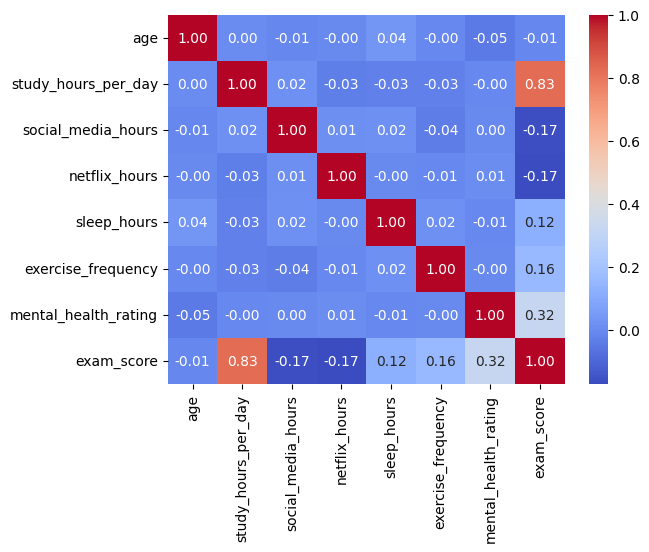

In [ ]:
# Mapa de calor utilizado para verficar correlação entre as variaveis numericas, o target é o exam_score(**deixar no eixo y) 

sns.heatmap(data=df[colunas].corr(), annot=True, cmap='coolwarm', fmt='.2f');

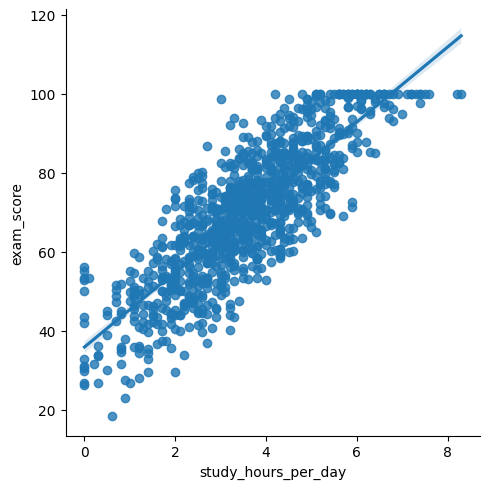

In [ ]:
#Correlação alta ; coeficiente angular alto, correlação alta

sns.lmplot(data=df, x='study_hours_per_day',y='exam_score')

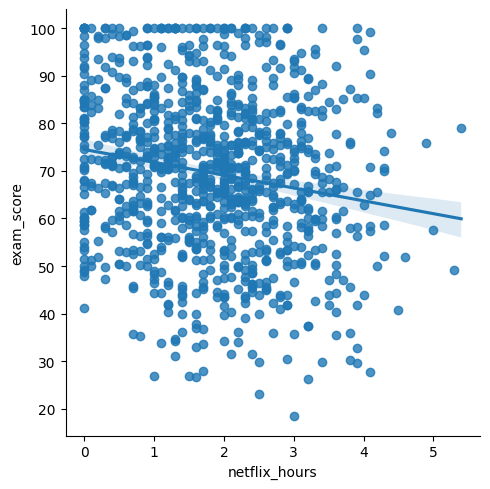

In [ ]:
#Correlação inversamente proporcional, coeficiente angular baixo = baixa correlaçãp

sns.lmplot(data=df, x='netflix_hours',y='exam_score')



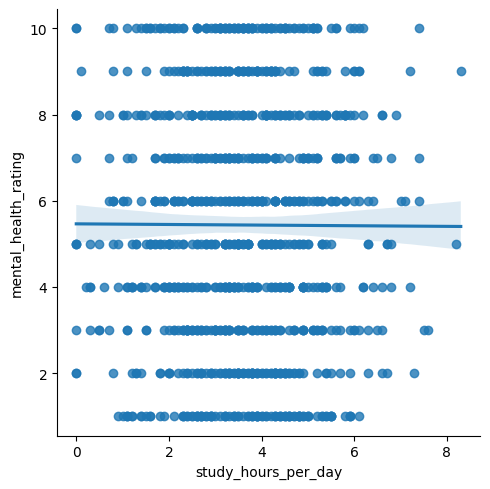

In [35]:
# Não existe correlação segundo os dados


sns.lmplot(data=df, x='study_hours_per_day',y='mental_health_rating')

In [ ]:
#Filtro segundo uma condição por horas estudadas 'filtro_horas_altas' 'filtro_horas_baixas'; as medias determinam quantas horas estudar para tirar certa nota.

filtro_horas_altas = df['study_hours_per_day'] >= 3
filtro_horas_baixas = df['study_hours_per_day'] < 2

media_alta = df[filtro_horas_altas]['exam_score'].mean()
media_baixa = df[filtro_horas_baixas]['exam_score'].mean()

print(media_alta)
print(media_baixa)

77.46456456456455
45.56390977443609


In [36]:
df.to_csv('dataset_06072026.csv')